# Crypto Momentum Strategy — Backtest
**Strategy:** 5-vs-30 day momentum with tanh signal normalization  
**Universe:** Binance crypto perpetuals (daily OHLCV)  
**Reference:** `src/Crypto_momentum.py`

In [1]:
import sys, os, importlib, warnings
warnings.filterwarnings('ignore')

# Dynamic path resolution for importing src modules
for path in ['src', '../src']:
    abs_path = os.path.abspath(os.path.join(os.getcwd(), path))
    if os.path.isdir(abs_path):
        if abs_path not in sys.path:
            sys.path.insert(0, abs_path)
        break

import Crypto_momentum
importlib.reload(Crypto_momentum)
from Crypto_momentum import fetch_binance_daily_closes

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import seaborn as sns
from itertools import product
import calendar

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

# ── Configuration ─────────────────────────────────────────────────────────────
TOKENS = [
    'AAVE', 'AIXBT', 'AVAX', 'BCH', 'BNB', 'BTC', 'COMP', 'DOGE', 'DOT', 'DYDX',
    'EIGEN', 'ENA', 'ETH', 'ETHFI', 'FORM', 'INJ', 'JUP', 'LTC', 'NEAR', 'PNUT',
    'RAY', 'SOL', 'SUI', 'TRX', 'UNI', 'WIF', 'XAU', 'XAG', 'NVDA', 'AMZN', 'GOOG',
]

START_DATE   = '2018-01-01'   # extra padding for max 60-day lookback
END_DATE     = pd.Timestamp.today().strftime('%Y-%m-%d')
FEE_RATE     = 0.0005         # 0.05% per-leg
SHORT_WINDOW = 5              # fast momentum window (t-7)
LONG_WINDOW  = 30             # slow momentum window (t-30)
EVAL_YEARS   = 5              # evaluation window
OUTPUTS_DIR  = os.path.join('outputs')
os.makedirs(OUTPUTS_DIR, exist_ok=True)

print(f'Config OK | Short={SHORT_WINDOW}d  Long={LONG_WINDOW}d  Fee={FEE_RATE*100:.2f}%  Eval={EVAL_YEARS}yr')
print(f'Date range: {START_DATE} → {END_DATE}')

Fetching historical data from Binance...
  Successfully loaded: AAVE
  Successfully loaded: AIXBT
  Successfully loaded: AVAX
  Successfully loaded: BCH
  Successfully loaded: BNB
  Successfully loaded: BTC
  Successfully loaded: COMP
  Successfully loaded: DOGE
  Successfully loaded: DOT
  Successfully loaded: DYDX
  Successfully loaded: EIGEN
  Successfully loaded: ENA
  Successfully loaded: ETH
  Successfully loaded: ETHFI
  Successfully loaded: FORM
  Successfully loaded: INJ
  Successfully loaded: JUP
  Successfully loaded: LTC
  Successfully loaded: NEAR
  Successfully loaded: PNUT
  Successfully loaded: RAY
  Successfully loaded: SOL
  Successfully loaded: SUI
  Successfully loaded: TRX
  Successfully loaded: UNI
  Successfully loaded: WIF
  Skipped (Not found/Insufficient data): XAU
  Skipped (Not found/Insufficient data): XAG
  Skipped (Not found/Insufficient data): BZ
  Skipped (Not found/Insufficient data): NVDA
  Skipped (Not found/Insufficient data): AMZN
  Skipped (Not fo

## 1 — Universe

In [2]:
UNIVERSE_META = {
    'AAVE': 'DeFi',   'AIXBT': 'AI',     'AVAX':  'L1',     'BCH':  'PoW',
    'BNB':  'CEX',    'BTC':   'PoW',    'COMP':  'DeFi',   'DOGE': 'Meme',
    'DOT':  'L0',     'DYDX':  'DeFi',   'EIGEN': 'LST',    'ENA':  'Stable',
    'ETH':  'L1',     'ETHFI': 'LST',    'FORM':  'Alt',    'INJ':  'L1',
    'JUP':  'DeFi',   'LTC':   'PoW',    'NEAR':  'L1',     'PNUT': 'Meme',
    'RAY':  'DeFi',   'SOL':   'L1',     'SUI':   'L1',     'TRX':  'L1',
    'UNI':  'DeFi',   'WIF':   'Meme',   'XAU':   'Macro',  'XAG':  'Macro',
    'NVDA': 'Equity', 'AMZN':  'Equity', 'GOOG':  'Equity',
}

universe_df = pd.DataFrame.from_dict(UNIVERSE_META, orient='index', columns=['Sector'])
display(universe_df.T)
print(f'\nTotal defined universe: {len(TOKENS)} assets')

,AAVE,AIXBT,AVAX,BCH,BNB,BTC,COMP,DOGE,DOT,DYDX,...,SOL,SUI,TRX,UNI,WIF,XAU,XAG,NVDA,AMZN,GOOG
Sector,DeFi,AI,L1,PoW,CEX,PoW,DeFi,Meme,L0,DeFi,...,L1,L1,L1,DeFi,Meme,Macro,Macro,Equity,Equity,Equity



Total defined universe: 31 assets


## 2 — Data Fetch

In [3]:
import requests as _req, time as _time

def fetch_binance_daily_ohlcv(symbol, start_date, end_date):
    """
    Fetch daily OHLCV bars from Binance public klines endpoint.
    Returns DataFrame with columns ['close', 'high', 'low'], DatetimeIndex.
    Returns None if symbol not found (HTTP 400) or no data.
    """
    url      = "https://api.binance.com/api/v3/klines"
    ticker   = f"{symbol}USDT"
    start_ts = int(pd.Timestamp(start_date).timestamp() * 1000)
    end_ts   = int(pd.Timestamp(end_date).timestamp() * 1000)
    data     = []

    while start_ts < end_ts:
        params = {'symbol': ticker, 'interval': '1d', 'startTime': start_ts, 'limit': 1000}
        try:
            r = _req.get(url, params=params, timeout=15)
            if r.status_code == 400:
                return None
            r.raise_for_status()
            klines = r.json()
            if not klines:
                break
            data.extend(klines)
            start_ts = klines[-1][0] + 86_400_000
            if len(klines) < 1000:
                break
            _time.sleep(0.1)
        except Exception:
            return None

    if not data:
        return None

    df = pd.DataFrame(data, columns=[
        'open_time', 'open', 'high', 'low', 'close', 'volume',
        'close_time', 'quote_volume', 'trades', 'tb_base', 'tb_quote', 'ignore'
    ])
    df['date'] = pd.to_datetime(df['open_time'], unit='ms')
    df = df.set_index('date')
    for col in ['close', 'high', 'low']:
        df[col] = df[col].astype(float)
    return df[['close', 'high', 'low']]


# ── Single-pass fetch: C, H, L collected together ────────────────────────────
MIN_BARS     = max(LONG_WINDOW, 60) + 10
ohlcv_series = {}
skipped      = []

for token in TOKENS:
    df_ohlcv = fetch_binance_daily_ohlcv(token, START_DATE, END_DATE)
    if df_ohlcv is not None and len(df_ohlcv) > MIN_BARS:
        ohlcv_series[token] = df_ohlcv
        print(f'  Loaded : {token:<8s}  ({len(df_ohlcv)} bars)')
    else:
        skipped.append(token)
        print(f'  Skipped: {token:<8s}  (not on Binance or insufficient history)')

# Build aligned DataFrames from the single fetch
df_prices = pd.DataFrame({t: ohlcv_series[t]['close'] for t in ohlcv_series}).sort_index().ffill()
df_high   = pd.DataFrame({t: ohlcv_series[t]['high']  for t in ohlcv_series}).sort_index().ffill()
df_low    = pd.DataFrame({t: ohlcv_series[t]['low']   for t in ohlcv_series}).sort_index().ffill()

ACTIVE_TOKENS = list(df_prices.columns)
OHLCV_TOKENS  = ACTIVE_TOKENS   # same universe — all three frames are aligned

assert df_prices.shape == df_high.shape == df_low.shape, "Shape mismatch between OHLCV frames"

print(f'\nActive universe : {len(ACTIVE_TOKENS)} assets')
print(f'Skipped         : {skipped}')
print(f'Date range      : {df_prices.index[0].date()} → {df_prices.index[-1].date()}')
print(f'Shape (C/H/L)   : {df_prices.shape}')

  Loaded : AAVE      (2091 bars)
  Loaded : AIXBT     (543 bars)
  Loaded : AVAX      (2114 bars)
  Loaded : BCH       (2413 bars)
  Loaded : BNB       (3109 bars)
  Loaded : BTC       (3109 bars)
  Loaded : COMP      (2203 bars)
  Loaded : DOGE      (2559 bars)
  Loaded : DOT       (2149 bars)
  Loaded : DYDX      (1762 bars)
  Loaded : EIGEN     (644 bars)
  Loaded : ENA       (826 bars)
  Loaded : ETH       (3109 bars)
  Loaded : ETHFI     (841 bars)
  Loaded : FORM      (475 bars)
  Loaded : INJ       (2085 bars)
  Loaded : JUP       (888 bars)
  Loaded : LTC       (3109 bars)
  Loaded : NEAR      (2092 bars)
  Loaded : PNUT      (603 bars)
  Loaded : RAY       (1792 bars)
  Loaded : SOL       (2156 bars)
  Loaded : SUI       (1161 bars)
  Loaded : TRX       (2948 bars)
  Loaded : UNI       (2119 bars)
  Loaded : WIF       (854 bars)
  Skipped: XAU       (not on Binance or insufficient history)
  Skipped: XAG       (not on Binance or insufficient history)
  Skipped: NVDA      (not 

### Turtle risk
Calculate N, and unit sizes for every asset:

In [4]:
# df_high / df_low / df_prices (close) are already built above in one API pass.
# df_close is a name alias so the ATR cell below uses the conventional variable name.
df_close = df_prices

assert df_high.shape == df_low.shape == df_close.shape, \
    f"OHLCV shape mismatch: H={df_high.shape} L={df_low.shape} C={df_close.shape}"

print(f"OHLCV frames aligned — shape: {df_high.shape}")
print(f"Date range: {df_close.index[0].date()} → {df_close.index[-1].date()}")

OHLCV frames aligned — shape: (3109, 26)
Date range: 2018-01-01 → 2026-07-06


In [5]:
from dataclasses import dataclass

# ── Turtle primitives (re-implemented inline — no external dependency) ─────────

@dataclass
class Candle:
    ts: int; o: float; h: float; l: float; c: float; v: float

def calc_n(candles: list, period: int = 20) -> float:
    """
    20-day EMA of True Range (Turtle N).
    Seed: SMA of first `period` TRs.  Then: N = ((period-1)*N_prev + TR) / period.
    Copied verbatim from shared/calibration/estimators.py logic.
    """
    tr = [candles[0].h - candles[0].l]
    for i in range(1, len(candles)):
        pdc = candles[i - 1].c
        tr.append(max(
            candles[i].h - candles[i].l,
            abs(candles[i].h - pdc),
            abs(pdc - candles[i].l),
        ))
    if len(tr) < period:
        raise ValueError(f"calc_n needs {period}+ candles, got {len(tr)}")
    n = sum(tr[:period]) / period        # SMA seed
    for t in tr[period:]:
        n = ((period - 1) * n + t) / period
    return n

ATR_PERIOD    = 20     # Turtle standard
RISK_PER_UNIT = 0.01   # 1% equity per unit
MAX_UNITS     = 4      # 4 units max per market

# ── Vectorized rolling ATR (N) for all assets ─────────────────────────────────

def build_rolling_atr(df_high, df_low, df_close, period=ATR_PERIOD):
    """
    Returns df_atr: same shape as inputs.
    Each cell = Turtle N (20-day EMA of True Range) computed causally.

    pandas ewm(span=period, adjust=False) implements:
        EMA_t = ((period-1)*EMA_{t-1} + TR_t) / period
    which is identical to Turtle's  N_t = (19*PDN + TR) / 20.

    Final shift(1) ensures only yesterday's N is used today (no lookahead).
    """
    prev_close = df_close.shift(1)
    hl  = df_high - df_low
    hpc = (df_high - prev_close).abs()
    lpc = (df_low  - prev_close).abs()
    tr  = pd.concat([hl, hpc, lpc], axis=0).groupby(level=0).max()

    df_atr = tr.ewm(span=period, min_periods=period, adjust=False).mean()
    return df_atr.shift(1)    # causal: use N from yesterday


df_atr   = build_rolling_atr(df_high, df_low, df_close)
df_n_pct = (df_atr / df_close).replace(0, np.nan)   # N as % of price

print(f'df_atr shape  : {df_atr.shape}')
print(f'NaN rows (warm-up): {df_atr.isna().all(axis=1).sum()}  (expected ≈ {ATR_PERIOD+1})')
print(f'\nATR sanity check — last 3 bars:')
for tok in ['BTC', 'ETH', 'SOL']:
    if tok in df_atr.columns:
        n_val   = df_atr[tok].dropna().iloc[-1]
        p_val   = df_close[tok].dropna().iloc[-1]
        n_pct   = n_val / p_val * 100
        print(f'  {tok:<6s}  N={n_val:>10,.2f}  Price={p_val:>10,.2f}  N%={n_pct:.2f}%')

df_atr shape  : (3109, 26)
NaN rows (warm-up): 20  (expected ≈ 21)

ATR sanity check — last 3 bars:
  BTC     N=  2,119.60  Price= 61,883.99  N%=3.43%
  ETH     N=     80.18  Price=  1,744.31  N%=4.60%
  SOL     N=      4.19  Price=     80.12  N%=5.23%


## 3 — KPI Computation

In [11]:
def compute_kpis(results):
    r  = results['eval_returns']
    cr = results['cum_returns']
    dd = results['drawdowns']
    n  = len(r)

    total_return = float(cr.iloc[-1] - 1)
    cagr         = float(cr.iloc[-1] ** (365.25 / n) - 1) if cr.iloc[-1] > 0 else -1.0
    max_dd       = float(dd.min())
    ann_ret      = float(r.mean() * 365)

    down_r       = r[r < 0]
    ann_down_std = float(down_r.std() * np.sqrt(365)) if len(down_r) > 1 else np.nan
    ann_std      = float(r.std() * np.sqrt(365))

    sortino      = ann_ret / ann_down_std if ann_down_std and not np.isnan(ann_down_std) else np.nan
    sharpe       = ann_ret / ann_std      if ann_std > 0 else np.nan

    eval_fees    = results['fees'].loc[r.index]
    total_fees   = float(eval_fees.sum())

    return dict(
        total_return = total_return,
        cagr         = cagr,
        max_dd       = max_dd,
        sortino      = sortino,
        sharpe       = sharpe,
        total_fees   = total_fees,
        short_w      = results['short_w'],
        long_w       = results['long_w'],
    )

kpis = compute_kpis(results)

# print('KPI Summary (baseline):')
# for k, v in kpis.items():
#     if isinstance(v, float):
#         pct = k in ('total_return', 'cagr', 'max_dd', 'total_fees')
#         print(f'  {k:<18s}: {v*100:+.2f}%' if pct else f'  {k:<18s}: {v:.4f}')
#     else:
#         print(f'  {k:<18s}: {v}')

## 4 — Backtest Engine

In [12]:
def run_momentum_backtest(df_prices, short_w=5, long_w=30, fee_rate=0.0005, eval_years=5, max_weight=0.20, stop_loss_pct=-0.10):
    """
    Dollar-neutral daily-rebalanced momentum backtest.

    Signal  : tanh((price[t-short_w] - price[t-long_w]) / price[t-long_w])
    Weights : signal / sum(|signal|)  →  gross exposure <= 1 (capped)
    Fees    : fee_rate * sum(|Δweight|) per day
    """
    df_returns  = df_prices.pct_change()
    df_momo     = (df_prices.shift(short_w) - df_prices.shift(long_w)) / df_prices.shift(long_w)
    df_raw_w    = np.tanh(df_momo)
    df_raw_w    = df_raw_w.where(df_prices.notna(), 0).fillna(0)

    total_abs   = df_raw_w.abs().sum(axis=1)
    df_w        = df_raw_w.div(total_abs.replace(0, np.nan), axis=0).fillna(0)
    
    # 1. Position Sizing Caps (Enforces diversification and allows < 1.0 gross exposure)
    if max_weight is not None:
        df_w = df_w.clip(lower=-max_weight, upper=max_weight)
        
    df_w_shift  = df_w.shift(1).fillna(0)

    # 2. Stop Loss Liquidation (Prevents allocating to assets that just crashed severely)
    if stop_loss_pct is not None:
        df_w_shift = df_w_shift.where(df_returns.shift(1) >= stop_loss_pct, 0)

    port_gross  = (df_w_shift * df_returns).sum(axis=1)
    wt_changes  = df_w_shift.diff().abs().sum(axis=1)
    wt_changes.iloc[0] = df_w_shift.iloc[0].abs().sum()
    fees        = wt_changes * fee_rate
    port_net    = port_gross - fees

    cutoff       = df_prices.index[-1] - pd.DateOffset(years=eval_years)
    eval_returns = port_net.loc[cutoff:]
    cum_returns  = (1 + eval_returns).cumprod()
    running_max  = cum_returns.cummax()
    drawdowns    = (cum_returns - running_max) / running_max

    return dict(
        eval_returns   = eval_returns,
        cum_returns    = cum_returns,
        drawdowns      = drawdowns,
        weights_shifted= df_w_shift,
        df_returns     = df_returns,
        df_momo        = df_momo,
        df_weights     = df_w,
        weight_changes = wt_changes,
        fees           = fees,
        short_w        = short_w,
        long_w         = long_w,
    )

results = run_momentum_backtest(
    df_prices, short_w=SHORT_WINDOW, long_w=LONG_WINDOW,
    fee_rate=FEE_RATE, eval_years=EVAL_YEARS, max_weight=0.10, stop_loss_pct=-0.15
)

print('Backtest complete.')
print(f"  Eval window : {results['eval_returns'].index[0].date()} → {results['eval_returns'].index[-1].date()}")
print(f"  Bars        : {len(results['eval_returns'])}")

Backtest complete.
  Eval window : 2021-07-06 → 2026-07-06
  Bars        : 1827


## 4b — Turtle N-Weight Backtest Engine

In [13]:
def run_turtle_backtest(
    df_prices,
    df_atr,
    short_w    = SHORT_WINDOW,
    long_w     = LONG_WINDOW,
    fee_rate   = FEE_RATE,
    eval_years = EVAL_YEARS,
):
    """
    Turtle N-based inverse-volatility momentum backtest.

    Direction : tanh of the same momentum signal used in run_momentum_backtest
    Magnitude : 1 / N_pct_i   (low-vol assets get proportionally more capital)
                This is the Turtle "equal risk per unit" principle — risk = ATR × qty
                so qty ∝ 1/ATR → equal dollar-risk per unit across assets.
    Weights   : raw = direction × (1/N_pct); normalized to gross exposure = 1.0
    Fees      : fee_rate × daily turnover (same model as momentum baseline)
    """
    # Align df_atr to df_prices columns (use intersection)
    common_cols = df_prices.columns.intersection(df_atr.columns)
    prices_  = df_prices[common_cols]
    atr_     = df_atr[common_cols].reindex(prices_.index)

    df_returns = prices_.pct_change()

    # ── Direction: same tanh momentum signal ─────────────────────────────────
    df_momo = (prices_.shift(short_w) - prices_.shift(long_w)) / prices_.shift(long_w)
    df_dir  = np.tanh(df_momo)
    df_dir  = df_dir.where(prices_.notna(), 0).fillna(0)

    # ── Magnitude: inverse N_pct (N_pct = ATR / price) ───────────────────────
    df_n_pct_aligned = (atr_ / prices_).replace(0, np.nan)
    df_inv_n         = 1.0 / df_n_pct_aligned          # large when vol is low
    df_inv_n         = df_inv_n.where(prices_.notna(), np.nan)

    # ── Raw turtle weight = direction × inverse_N ────────────────────────────
    df_raw_w = df_dir * df_inv_n
    df_raw_w = df_raw_w.fillna(0)

    # ── Normalize to gross exposure = 1.0 ────────────────────────────────────
    total_abs = df_raw_w.abs().sum(axis=1)
    df_w      = df_raw_w.div(total_abs.replace(0, np.nan), axis=0).fillna(0)
    df_w_shift= df_w.shift(1).fillna(0)    # execute at next bar open

    # ── P&L ──────────────────────────────────────────────────────────────────
    port_gross   = (df_w_shift * df_returns).sum(axis=1)
    wt_changes   = df_w_shift.diff().abs().sum(axis=1)
    wt_changes.iloc[0] = df_w_shift.iloc[0].abs().sum()
    fees         = wt_changes * fee_rate
    port_net     = port_gross - fees

    cutoff       = prices_.index[-1] - pd.DateOffset(years=eval_years)
    eval_returns = port_net.loc[cutoff:]
    cum_returns  = (1 + eval_returns).cumprod()
    running_max  = cum_returns.cummax()
    drawdowns    = (cum_returns - running_max) / running_max

    return dict(
        eval_returns   = eval_returns,
        cum_returns    = cum_returns,
        drawdowns      = drawdowns,
        weights_shifted= df_w_shift,
        df_returns     = df_returns,
        df_momo        = df_momo,
        df_weights     = df_w,
        df_atr         = atr_,
        df_n_pct       = df_n_pct_aligned,
        weight_changes = wt_changes,
        fees           = fees,
        short_w        = short_w,
        long_w         = long_w,
    )


results_turtle = run_turtle_backtest(df_prices, df_atr)
kpis_turtle    = compute_kpis(results_turtle)

print('Turtle backtest complete.')
print(f"  Eval window : {results_turtle['eval_returns'].index[0].date()} → {results_turtle['eval_returns'].index[-1].date()}")
print(f"  Assets      : {results_turtle['df_weights'].shape[1]}")
print()
print('KPI Summary (Turtle N-Weight):')
for k, v in kpis_turtle.items():
    if isinstance(v, float):
        pct = k in ('total_return', 'cagr', 'max_dd', 'total_fees')
        print(f'  {k:<18s}: {v*100:+.2f}%' if pct else f'  {k:<18s}: {v:.4f}')
    elif isinstance(v, int):
        print(f'  {k:<18s}: {v}')

Turtle backtest complete.
  Eval window : 2021-07-06 → 2026-07-06
  Assets      : 26

KPI Summary (Turtle N-Weight):
  total_return      : +256.13%
  cagr              : +28.91%
  max_dd            : -54.35%
  sortino           : 1.1032
  sharpe            : 0.7167
  total_fees        : +25.68%
  short_w           : 5
  long_w            : 30


## 4c — Strategy Comparison: Tanh-Momentum vs Turtle N-Weight

Saved → outputs\Momentum_vs_Turtle_equity.png


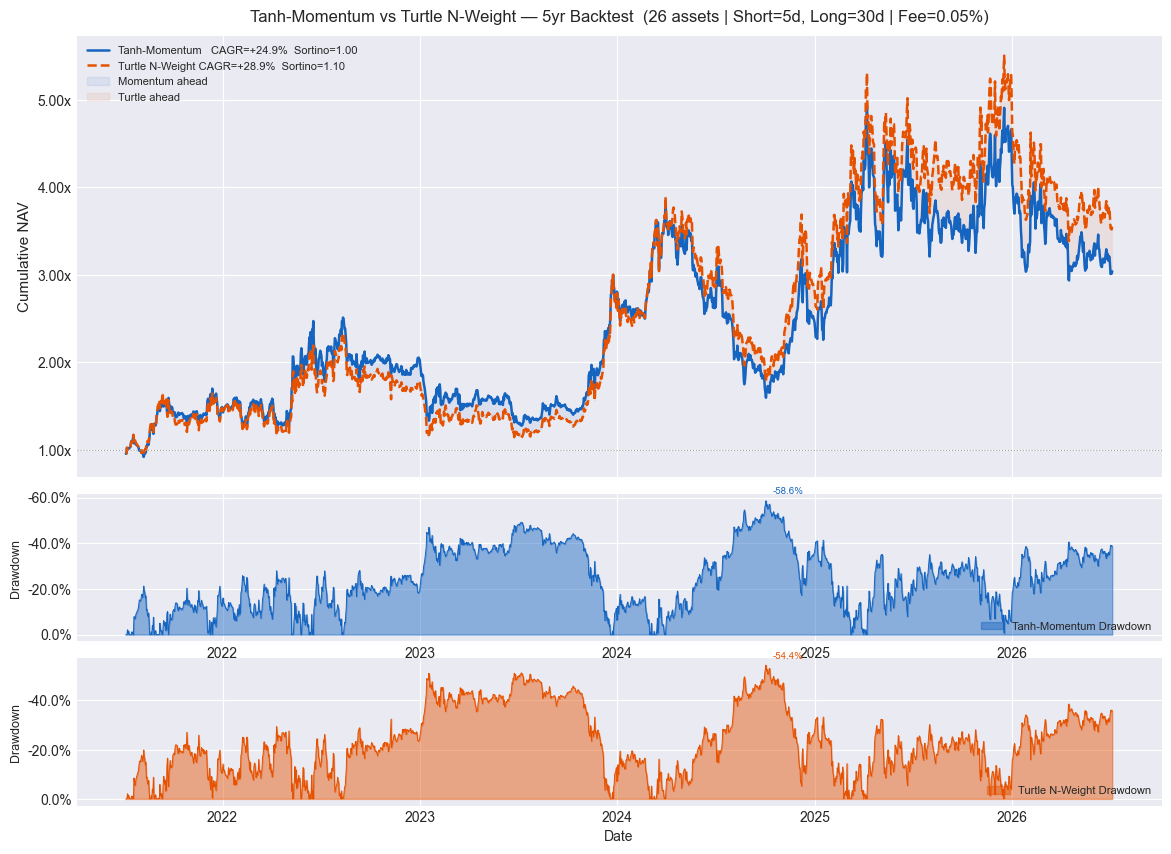

,Tanh-Momentum,Turtle N-Weight
Total Return,+204.13%,+256.13%
CAGR,+24.90%,+28.91%
Max Drawdown,-58.57%,-54.35%
Sortino Ratio,1.004,1.103
Sharpe Ratio,0.666,0.717
Total Fee Drag,+22.02%,+25.68%


In [14]:
cum_m = results['cum_returns']
cum_t = results_turtle['cum_returns']
dd_m  = results['drawdowns'] * 100
dd_t  = results_turtle['drawdowns'] * 100

# ── 3-panel chart ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(3, 1, height_ratios=[3, 1, 1], hspace=0.07)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharex=ax1)
ax3 = fig.add_subplot(gs[2], sharex=ax1)

# Equity curves on same axis
ax1.plot(cum_m.index, cum_m.values, color='#1565C0', linewidth=1.8,
         label=f'Tanh-Momentum   CAGR={kpis["cagr"]*100:+.1f}%  Sortino={kpis["sortino"]:.2f}')
ax1.plot(cum_t.index, cum_t.values, color='#E65100', linewidth=1.8, linestyle='--',
         label=f'Turtle N-Weight CAGR={kpis_turtle["cagr"]*100:+.1f}%  Sortino={kpis_turtle["sortino"]:.2f}')
ax1.axhline(1.0, color='#9E9E9E', lw=0.8, linestyle=':')
ax1.fill_between(cum_m.index, cum_m.values, cum_t.values,
                 where=cum_m.values >= cum_t.values, alpha=0.08, color='#1565C0', label='Momentum ahead')
ax1.fill_between(cum_m.index, cum_m.values, cum_t.values,
                 where=cum_m.values < cum_t.values,  alpha=0.08, color='#E65100', label='Turtle ahead')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.2f}x'))
ax1.set_ylabel('Cumulative NAV', fontsize=11)
ax1.set_title(
    f'Tanh-Momentum vs Turtle N-Weight — {EVAL_YEARS}yr Backtest  ({len(ACTIVE_TOKENS)} assets | '
    f'Short={SHORT_WINDOW}d, Long={LONG_WINDOW}d | Fee={FEE_RATE*100:.2f}%)',
    fontsize=12, pad=10,
)
ax1.legend(loc='upper left', fontsize=8)
plt.setp(ax1.get_xticklabels(), visible=False)

# Individual drawdown panels
for ax, dd, color, label in [
    (ax2, dd_m, '#1565C0', 'Tanh-Momentum Drawdown'),
    (ax3, dd_t, '#E65100', 'Turtle N-Weight Drawdown'),
]:
    ax.fill_between(dd.index, dd.values, color=color, alpha=0.45, label=label)
    ax.plot(dd.index, dd.values, color=color, linewidth=0.7)
    ax.invert_yaxis()
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))
    ax.set_ylabel('Drawdown', fontsize=9)
    ax.legend(loc='lower right', fontsize=8)
    max_dd_date = dd.idxmin()
    ax.annotate(f'{dd.min():.1f}%', xy=(max_dd_date, dd.min()),
                xytext=(5, 5), textcoords='offset points', fontsize=7, color=color)

ax3.set_xlabel('Date', fontsize=10)
fig.tight_layout()
out_png = os.path.join(OUTPUTS_DIR, 'Momentum_vs_Turtle_equity.png')
fig.savefig(out_png, dpi=150, bbox_inches='tight')
print(f'Saved → {out_png}')
plt.show()

# ── KPI comparison table ──────────────────────────────────────────────────────
metric_labels = {
    'total_return': 'Total Return',
    'cagr':         'CAGR',
    'max_dd':       'Max Drawdown',
    'sortino':      'Sortino Ratio',
    'sharpe':       'Sharpe Ratio',
    'total_fees':   'Total Fee Drag',
}

compare_data = {}
for key, label in metric_labels.items():
    compare_data[label] = {
        'Tanh-Momentum':   kpis[key],
        'Turtle N-Weight': kpis_turtle[key],
    }
kpi_compare = pd.DataFrame(compare_data).T

pct_rows  = ['Total Return', 'CAGR', 'Max Drawdown', 'Total Fee Drag']
ratio_rows= ['Sortino Ratio', 'Sharpe Ratio']

def fmt_kpi(val, row):
    if row in pct_rows:
        return f'{val*100:+.2f}%'
    return f'{val:.3f}'

kpi_compare_fmt = kpi_compare.copy().astype(str)
for row in kpi_compare.index:
    for col in kpi_compare.columns:
        kpi_compare_fmt.loc[row, col] = fmt_kpi(kpi_compare.loc[row, col], row)

display(
    kpi_compare.style
    .format(lambda v: f'{v*100:+.2f}%', subset=pd.IndexSlice[pct_rows, :])
    .format(lambda v: f'{v:.3f}',        subset=pd.IndexSlice[ratio_rows, :])
    .background_gradient(cmap='RdYlGn', axis=1)
    .set_caption('Strategy Comparison: Tanh-Momentum vs Turtle N-Weight')
)

## 5 — Equity Curve & Drawdown

Saved → outputs\Momentum_equity_curve.png


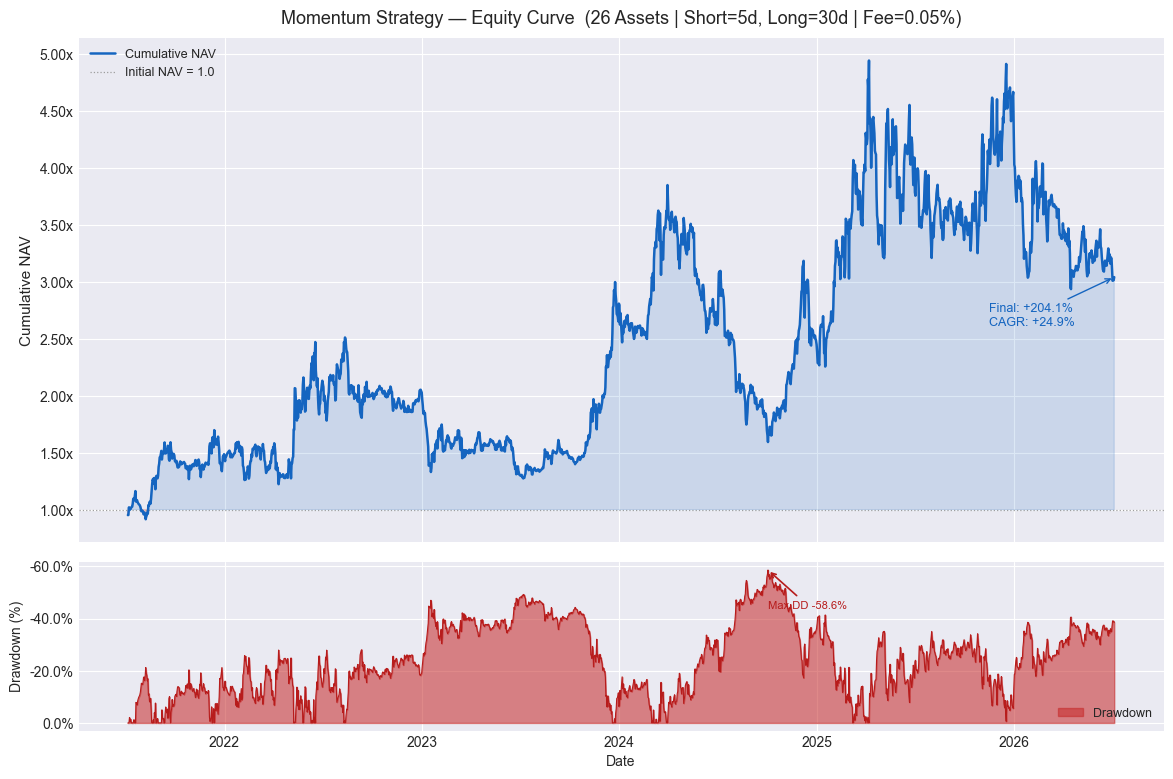

In [15]:
cum = results['cum_returns']
dd  = results['drawdowns'] * 100

fig = plt.figure(figsize=(14, 9))
gs  = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.06)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharex=ax1)

# ── Equity panel ──────────────────────────────────────────────────────────────
ax1.plot(cum.index, cum.values, color='#1565C0', linewidth=1.8,
         label='Cumulative NAV', zorder=3)
ax1.axhline(1.0, color='#9E9E9E', linewidth=0.9, linestyle=':', label='Initial NAV = 1.0')
ax1.fill_between(cum.index, 1.0, cum.values,
                 where=cum.values >= 1.0, alpha=0.15, color='#1565C0')
ax1.fill_between(cum.index, 1.0, cum.values,
                 where=cum.values < 1.0,  alpha=0.22, color='#C62828')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.2f}x'))
ax1.set_ylabel('Cumulative NAV', fontsize=11)
ax1.set_title(
    f'Momentum Strategy — Equity Curve  '
    f'({len(ACTIVE_TOKENS)} Assets | Short={SHORT_WINDOW}d, Long={LONG_WINDOW}d | Fee={FEE_RATE*100:.2f}%)',
    fontsize=13, pad=10,
)
ax1.legend(loc='upper left', fontsize=9)
plt.setp(ax1.get_xticklabels(), visible=False)

final_val = float(cum.iloc[-1])
ax1.annotate(
    f'Final: {kpis["total_return"]*100:+.1f}%\nCAGR: {kpis["cagr"]*100:+.1f}%',
    xy=(cum.index[-1], final_val),
    xytext=(-90, -35), textcoords='offset points',
    fontsize=9, color='#1565C0',
    arrowprops=dict(arrowstyle='->', color='#1565C0', lw=1.0),
)

# ── Drawdown panel ────────────────────────────────────────────────────────────
ax2.fill_between(dd.index, dd.values, color='#C62828', alpha=0.55, label='Drawdown')
ax2.plot(dd.index, dd.values, color='#B71C1C', linewidth=0.8)
ax2.set_ylabel('Drawdown (%)', fontsize=10)
ax2.set_xlabel('Date', fontsize=10)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))
ax2.invert_yaxis()
ax2.legend(loc='lower right', fontsize=9)

max_dd_date = dd.idxmin()
ax2.annotate(
    f'Max DD {dd.min():.1f}%',
    xy=(max_dd_date, dd.min()),
    xytext=(max_dd_date, dd.min() - dd.min() * 0.25),
    fontsize=8, color='#B71C1C',
    arrowprops=dict(arrowstyle='->', color='#B71C1C', lw=1.2),
)

fig.tight_layout()
out_png = os.path.join(OUTPUTS_DIR, 'Momentum_equity_curve.png')
fig.savefig(out_png, dpi=150, bbox_inches='tight')
print(f'Saved → {out_png}')
plt.show()

## 6 — Per-Asset Contribution Table

In [16]:
eval_idx     = results['eval_returns'].index
ws           = results['weights_shifted'].loc[eval_idx]
ret          = results['df_returns'].loc[eval_idx]
momo_eval    = results['df_momo'].loc[eval_idx]
asset_contrib= (ws * ret)

contrib_stats = pd.DataFrame({
    'Cum Contrib':     asset_contrib.sum(),
    'Ann Contrib %':   asset_contrib.mean() * 365 * 100,
    'Avg Weight':      ws.abs().mean(),
    'Avg Signal':      momo_eval.mean(),
    'Hit Rate %':      (asset_contrib > 0).mean() * 100,
    'Sharpe Contrib':  asset_contrib.mean() / asset_contrib.std() * np.sqrt(365),
}).sort_values('Cum Contrib', ascending=False)

contrib_stats['Sector'] = pd.Series(UNIVERSE_META).reindex(contrib_stats.index)

fmt = {
    'Cum Contrib':    '{:+.4f}',
    'Ann Contrib %':  '{:+.2f}%',
    'Avg Weight':     '{:.4f}',
    'Avg Signal':     '{:+.4f}',
    'Hit Rate %':     '{:.1f}%',
    'Sharpe Contrib': '{:.2f}',
}

display(
    contrib_stats.style
    .format(fmt)
    .background_gradient(subset=['Cum Contrib'],    cmap='RdYlGn', vmin=-0.3, vmax=0.3)
    .background_gradient(subset=['Sharpe Contrib'], cmap='RdYlGn', vmin=-1,   vmax=2)
    .background_gradient(subset=['Hit Rate %'],     cmap='RdYlGn', vmin=40,   vmax=60)
    .set_caption(f'Per-Asset P&L Contribution — Short={SHORT_WINDOW}d  Long={LONG_WINDOW}d')
)

,Cum Contrib,Ann Contrib %,Avg Weight,Avg Signal,Hit Rate %,Sharpe Contrib,Sector
RAY,+0.4946,+10.08%,0.0568,+0.0354,48.8%,1.12,DeFi
SOL,+0.3072,+6.14%,0.0500,+0.0598,50.8%,1.01,L1
AVAX,+0.2938,+5.87%,0.0505,+0.0413,50.5%,0.90,L1
NEAR,+0.2657,+5.31%,0.0568,+0.0479,48.7%,0.67,L1
SUI,+0.1788,+5.63%,0.0298,+0.0308,31.6%,0.93,L1
DYDX,+0.1645,+3.41%,0.0495,-0.0262,46.0%,0.48,DeFi
ENA,+0.1515,+6.70%,0.0237,-0.0215,22.3%,0.79,Stable
ETH,+0.1320,+2.64%,0.0367,+0.0138,50.2%,0.82,L1
INJ,+0.1088,+2.17%,0.0516,+0.0427,48.3%,0.29,L1
UNI,+0.0942,+1.88%,0.0462,+0.0017,50.5%,0.33,DeFi


## 7 — Performance Dashboard

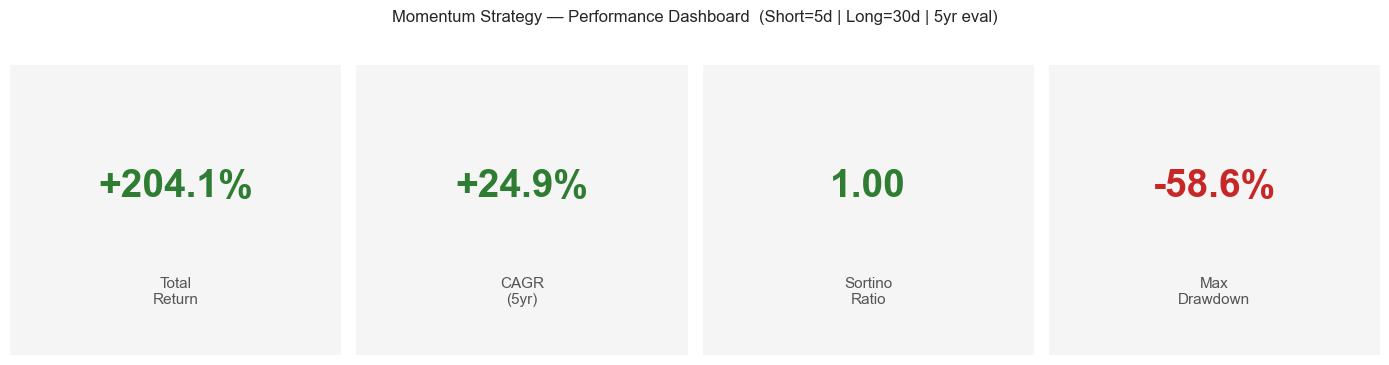

In [17]:
sortino_val = kpis['sortino']

metrics_display = [
    ('Total\nReturn',  f"{kpis['total_return']*100:+.1f}%",
     '#2E7D32' if kpis['total_return'] > 0 else '#C62828'),
    ('CAGR\n(5yr)',    f"{kpis['cagr']*100:+.1f}%",
     '#2E7D32' if kpis['cagr'] > 0 else '#C62828'),
    ('Sortino\nRatio', f"{sortino_val:.2f}" if not np.isnan(sortino_val) else 'N/A',
     '#2E7D32' if (not np.isnan(sortino_val) and sortino_val > 1) else '#E65100'),
    ('Max\nDrawdown',  f"{kpis['max_dd']*100:.1f}%", '#C62828'),
]

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for ax, (label, value, color) in zip(axes, metrics_display):
    ax.set_facecolor('#F5F5F5')
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.text(0.5, 0.58, value,  ha='center', va='center',
            fontsize=28, fontweight='bold', color=color, transform=ax.transAxes)
    ax.text(0.5, 0.22, label,  ha='center', va='center',
            fontsize=11, color='#555', transform=ax.transAxes)
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle(
    f'Momentum Strategy — Performance Dashboard  (Short={SHORT_WINDOW}d | Long={LONG_WINDOW}d | {EVAL_YEARS}yr eval)',
    fontsize=12, y=1.03,
)
plt.tight_layout()
plt.show()

## 8 — Momentum Signal Visualization (Single Asset)

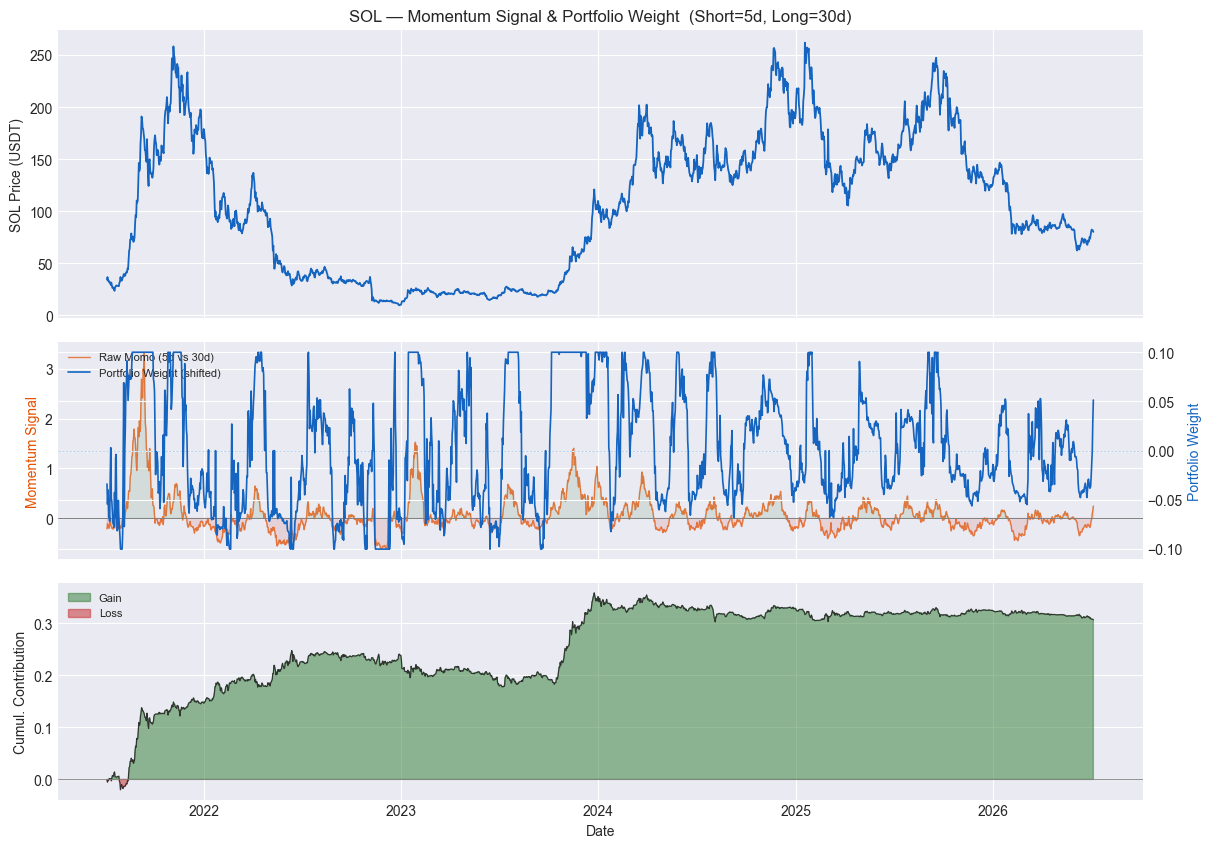


SOL Signal Stats (5yr eval window):
  Avg momentum     : +0.0598
  Signal std       : 0.3793
  Avg abs weight   : 0.0500
  Days long  (w>0) : 864 (47.3%)
  Days short (w<0) : 955 (52.3%)
  Cum contribution : +0.3072


In [18]:
SHOW_ASSET = 'SOL'   # ← change to any active token

assert SHOW_ASSET in ACTIVE_TOKENS, f'{SHOW_ASSET} not in active universe: {ACTIVE_TOKENS}'

eval_idx  = results['eval_returns'].index
prices    = df_prices[SHOW_ASSET].loc[eval_idx]
momo      = results['df_momo'][SHOW_ASSET].loc[eval_idx]
weight    = results['weights_shifted'][SHOW_ASSET].loc[eval_idx]
asset_r   = results['df_returns'][SHOW_ASSET].loc[eval_idx]
contrib   = (weight * asset_r).cumsum()

fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(3, 1, height_ratios=[2, 1.5, 1.5], hspace=0.10)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharex=ax1)
ax3 = fig.add_subplot(gs[2], sharex=ax1)

# Price
ax1.plot(prices.index, prices.values, color='#1565C0', linewidth=1.3)
ax1.set_ylabel(f'{SHOW_ASSET} Price (USDT)', fontsize=10)
ax1.set_title(
    f'{SHOW_ASSET} — Momentum Signal & Portfolio Weight  '
    f'(Short={SHORT_WINDOW}d, Long={LONG_WINDOW}d)',
    fontsize=12,
)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.setp(ax1.get_xticklabels(), visible=False)

# Signal + weight
ax2.plot(momo.index, momo.values, color='#E65100', linewidth=1.0, alpha=0.7,
         label=f'Raw Momo ({SHORT_WINDOW}d vs {LONG_WINDOW}d)')
ax2.axhline(0, color='grey', linewidth=0.7)
ax2.fill_between(momo.index, 0, momo.values,
                 where=momo.values >= 0, alpha=0.12, color='#2E7D32')
ax2.fill_between(momo.index, 0, momo.values,
                 where=momo.values < 0,  alpha=0.12, color='#C62828')
ax2.set_ylabel('Momentum Signal', color='#E65100', fontsize=10)

ax2b = ax2.twinx()
ax2b.plot(weight.index, weight.values, color='#1565C0', linewidth=1.2,
          label='Portfolio Weight (shifted)')
ax2b.set_ylabel('Portfolio Weight', color='#1565C0', fontsize=10)
ax2b.axhline(0, color='#1565C0', linewidth=0.5, linestyle='--', alpha=0.4)

lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=8)
plt.setp(ax2.get_xticklabels(), visible=False)

# Cumulative contribution
ax3.fill_between(contrib.index, 0, contrib.values,
                 where=contrib.values >= 0, alpha=0.5, color='#2E7D32', label='Gain')
ax3.fill_between(contrib.index, 0, contrib.values,
                 where=contrib.values < 0,  alpha=0.5, color='#C62828', label='Loss')
ax3.plot(contrib.index, contrib.values, color='#333', linewidth=0.8)
ax3.axhline(0, color='grey', linewidth=0.6)
ax3.set_ylabel('Cumul. Contribution', fontsize=10)
ax3.set_xlabel('Date', fontsize=10)
ax3.legend(loc='upper left', fontsize=8)

fig.tight_layout()
plt.show()

print(f'\n{SHOW_ASSET} Signal Stats ({EVAL_YEARS}yr eval window):')
print(f'  Avg momentum     : {momo.mean():+.4f}')
print(f'  Signal std       : {momo.std():.4f}')
print(f'  Avg abs weight   : {weight.abs().mean():.4f}')
print(f'  Days long  (w>0) : {(weight>0).sum()} ({(weight>0).mean()*100:.1f}%)')
print(f'  Days short (w<0) : {(weight<0).sum()} ({(weight<0).mean()*100:.1f}%)')
print(f'  Cum contribution : {contrib.iloc[-1]:+.4f}')

## 9 — Parameter Sensitivity Analysis

  ( 5,21) → CAGR=+9.2%  Sortino=0.72  MaxDD=-77.1%
  ( 5,30) → CAGR=+23.9%  Sortino=0.99  MaxDD=-63.1%
  ( 5,60) → CAGR=+3.3%  Sortino=0.54  MaxDD=-73.3%
  ( 7,21) → CAGR=+1.2%  Sortino=0.54  MaxDD=-75.1%
  ( 7,30) → CAGR=+22.6%  Sortino=0.98  MaxDD=-57.8%
  ( 7,60) → CAGR=-4.0%  Sortino=0.37  MaxDD=-79.6%
  (14,21) → CAGR=-12.2%  Sortino=0.18  MaxDD=-85.5%
  (14,30) → CAGR=+11.8%  Sortino=0.76  MaxDD=-68.7%
  (14,60) → CAGR=-10.4%  Sortino=0.23  MaxDD=-85.0%

Saved → outputs\Momentum_sensitivity.png


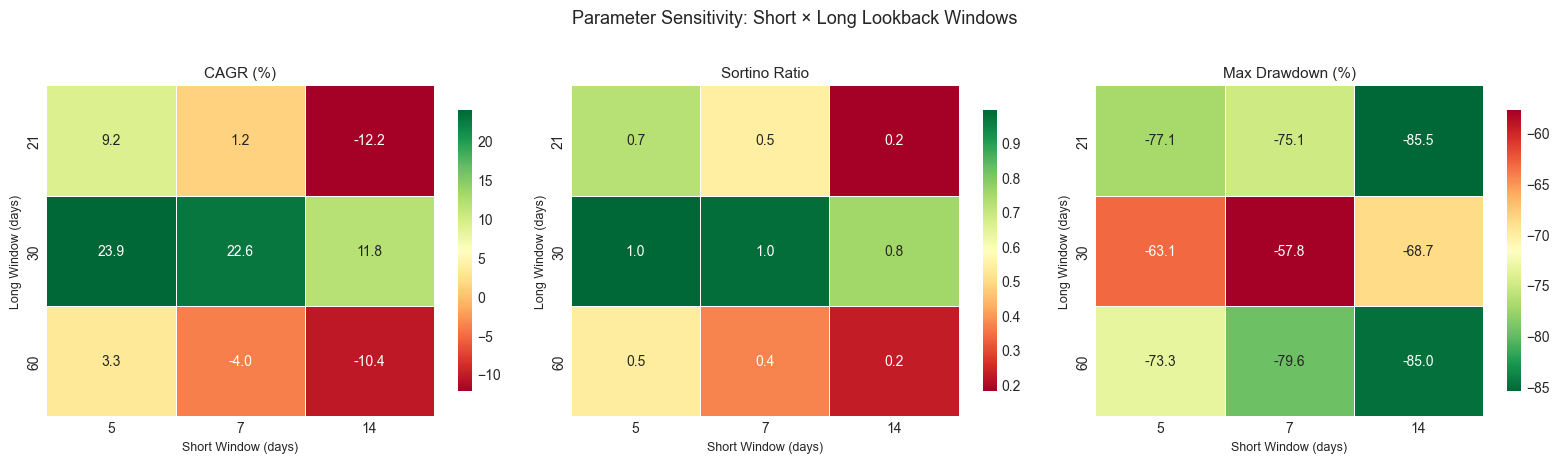


Top 5 configs by Sortino:


,short_w,long_w,cagr,sortino,max_dd,total_fees
1,5,30,+23.85%,0.99,-63.08%,0.2781
4,7,30,+22.65%,0.98,-57.75%,0.2920
7,14,30,+11.84%,0.76,-68.67%,0.3405
0,5,21,+9.18%,0.72,-77.14%,0.3428
3,7,21,+1.22%,0.54,-75.08%,0.3630


In [19]:
SHORT_WINDOWS = [5, 7, 14]
LONG_WINDOWS  = [21, 30, 60]

records = []
for sw, lw in product(SHORT_WINDOWS, LONG_WINDOWS):
    if sw >= lw:
        continue
    r = run_momentum_backtest(df_prices, short_w=sw, long_w=lw,
                              fee_rate=FEE_RATE, eval_years=EVAL_YEARS)
    k = compute_kpis(r)
    records.append(k)
    print(f'  ({sw:2d},{lw:2d}) → CAGR={k["cagr"]*100:+.1f}%  '
          f'Sortino={k["sortino"]:.2f}  MaxDD={k["max_dd"]*100:.1f}%')

sensitivity_df = pd.DataFrame(records)

def make_heatmap_pivot(df, col):
    d = df[['short_w', 'long_w', col]].copy()
    d['short_w'] = d['short_w'].astype(int)
    d['long_w']  = d['long_w'].astype(int)
    return d.pivot(index='long_w', columns='short_w', values=col)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig.suptitle('Parameter Sensitivity: Short × Long Lookback Windows', fontsize=13, y=1.02)

kpi_map = [
    ('cagr',    'CAGR (%)',         'RdYlGn',   True),
    ('sortino', 'Sortino Ratio',    'RdYlGn',   False),
    ('max_dd',  'Max Drawdown (%)', 'RdYlGn_r', True),
]

for ax, (col, title, cmap, as_pct) in zip(axes, kpi_map):
    piv = make_heatmap_pivot(sensitivity_df, col)
    if as_pct:
        piv = piv * 100
    sns.heatmap(
        piv, ax=ax, cmap=cmap, annot=True, fmt='.1f',
        linewidths=0.5, linecolor='white',
        cbar_kws={'shrink': 0.85},
    )
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Short Window (days)', fontsize=9)
    ax.set_ylabel('Long Window (days)',  fontsize=9)

plt.tight_layout()
out_png = os.path.join(OUTPUTS_DIR, 'Momentum_sensitivity.png')
fig.savefig(out_png, dpi=150, bbox_inches='tight')
print(f'\nSaved → {out_png}')
plt.show()

print('\nTop 5 configs by Sortino:')
top5 = (
    sensitivity_df
    .sort_values('sortino', ascending=False)
    .head(5)
    [['short_w', 'long_w', 'cagr', 'sortino', 'max_dd', 'total_fees']]
)
display(
    top5.style.format({
        'short_w': '{:.0f}', 'long_w': '{:.0f}',
        'cagr': '{:+.2%}', 'sortino': '{:.2f}',
        'max_dd': '{:.2%}', 'total_fees': '{:.4f}',
    })
)

## 10 — Monthly P&L Heatmap

Saved → outputs\Momentum_monthly_heatmap.png


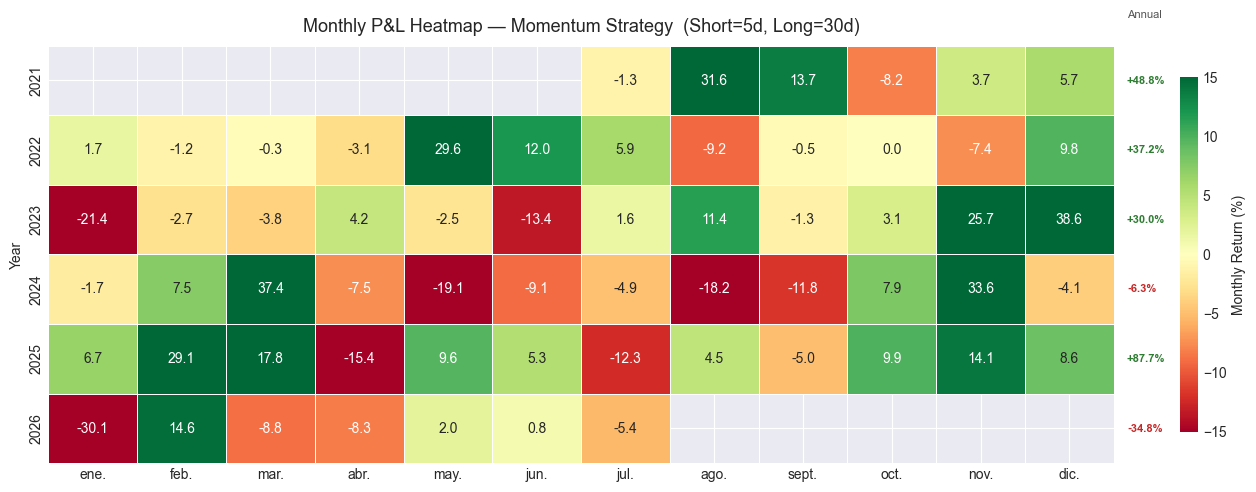


Monthly return stats (5yr eval):
  Best month   : 2023-12  +38.63%
  Worst month  : 2026-01  -30.14%
  Positive months: 32 / 61  (52.5%)


In [20]:
eval_r    = results['eval_returns']
monthly_r = (1 + eval_r).resample('ME').prod() - 1

pivot = pd.DataFrame({
    'Year':   monthly_r.index.year,
    'Month':  monthly_r.index.month,
    'Return': monthly_r.values,
}).pivot(index='Year', columns='Month', values='Return')

pivot.columns = [calendar.month_abbr[m] for m in pivot.columns]

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    pivot * 100,
    ax=ax,
    cmap='RdYlGn',
    center=0,
    annot=True, fmt='.1f',
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Monthly Return (%)', 'shrink': 0.85},
    vmin=-15, vmax=15,
)
ax.set_title(
    f'Monthly P&L Heatmap — Momentum Strategy  '
    f'(Short={SHORT_WINDOW}d, Long={LONG_WINDOW}d)',
    fontsize=13, pad=10,
)
ax.set_xlabel('')
ax.set_ylabel('Year', fontsize=10)

annual_r = (1 + eval_r).resample('YE').prod() - 1
for i, (yr_ts, ann) in enumerate(annual_r.items()):
    yr = yr_ts.year if hasattr(yr_ts, 'year') else yr_ts
    if yr in pivot.index:
        row_i = list(pivot.index).index(yr)
        c = '#2E7D32' if ann > 0 else '#C62828'
        ax.text(len(pivot.columns) + 0.15, row_i + 0.5,
                f'{ann*100:+.1f}%', va='center', fontsize=8,
                color=c, fontweight='bold')
ax.text(len(pivot.columns) + 0.15, -0.4, 'Annual', fontsize=8, color='#555')

fig.tight_layout()
out_png = os.path.join(OUTPUTS_DIR, 'Momentum_monthly_heatmap.png')
fig.savefig(out_png, dpi=150, bbox_inches='tight')
print(f'Saved → {out_png}')
plt.show()

flat = monthly_r.dropna()
print(f'\nMonthly return stats ({EVAL_YEARS}yr eval):')
print(f'  Best month   : {flat.idxmax().strftime("%Y-%m")}  {flat.max()*100:+.2f}%')
print(f'  Worst month  : {flat.idxmin().strftime("%Y-%m")}  {flat.min()*100:+.2f}%')
print(f'  Positive months: {(flat>0).sum()} / {len(flat)}  ({(flat>0).mean()*100:.1f}%)')

## 11 — Latest Portfolio Weights

Signal computed on  : 2026-07-06  (weights to be executed NEXT bar)
Last executed on    : 2026-07-06
Gross exposure check: 0.925593  (should be ≈ 1.0)



,Signal Weight (t),Executed Weight (t-1),Momentum Signal,Price,Direction
AAVE,+0.1000,+0.1000,+0.3650,93.2600,LONG
JUP,+0.1000,+0.1000,+0.5360,0.2386,LONG
SOL,+0.0786,+0.0515,+0.2453,80.1200,LONG
EIGEN,+0.0682,+0.0764,+0.2119,0.2245,LONG
RAY,+0.0525,+0.0191,+0.1620,0.7076,LONG
UNI,+0.0426,+0.0420,+0.1310,3.1270,LONG
ETHFI,+0.0362,+0.0399,+0.1111,0.4190,LONG
WIF,+0.0331,+0.0275,+0.1017,0.1705,LONG
DYDX,+0.0237,+0.0913,+0.0725,0.1313,LONG
PNUT,+0.0106,+0.0074,+0.0324,0.0444,LONG


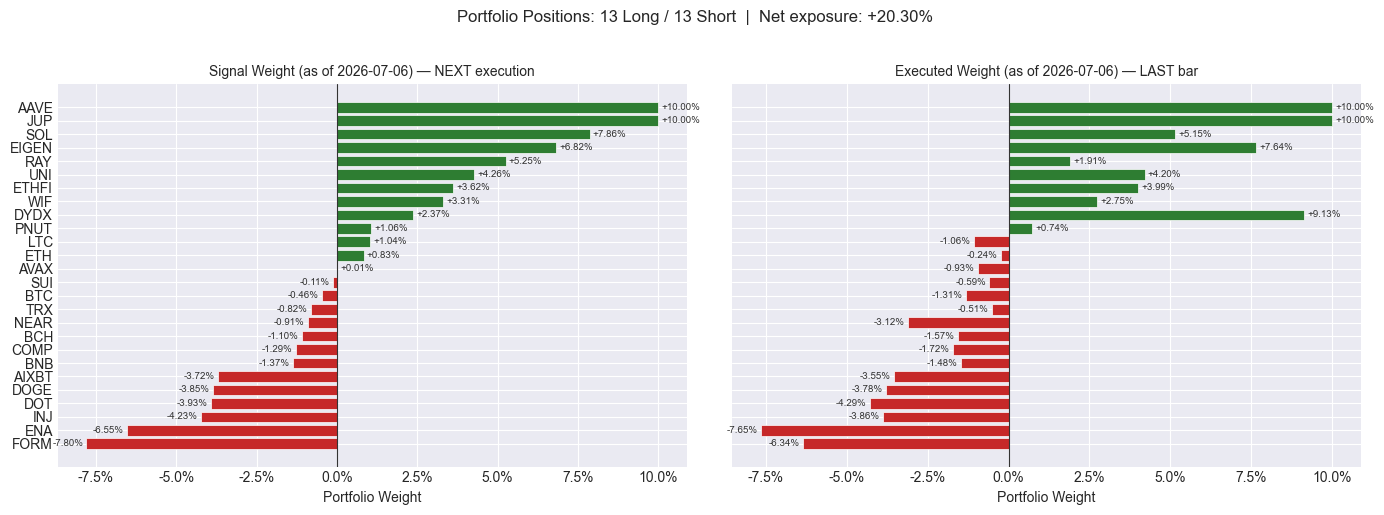


Top 3 LONG  : AAVE, JUP, SOL
Top 3 SHORT : INJ, ENA, FORM


In [21]:
# ── Latest weights ────────────────────────────────────────────────────────────
# df_weights      : signal computed on day t  → executed on day t+1 (forward-looking)
# weights_shifted : weight actually used on the last backtested day (lag-1 of above)

last_date_signal   = results['df_weights'].index[-1]
last_date_executed = results['weights_shifted'].index[-1]

w_current  = results['df_weights'].iloc[-1].sort_values(ascending=False)   # today's signal
w_executed = results['weights_shifted'].iloc[-1].sort_values(ascending=False)  # last executed

# ── Summary table ─────────────────────────────────────────────────────────────
weight_table = pd.DataFrame({
    'Signal Weight (t)'    : results['df_weights'].iloc[-1],
    'Executed Weight (t-1)': results['weights_shifted'].iloc[-1],
    'Momentum Signal'      : results['df_momo'].iloc[-1],
    'Price'                : df_prices.iloc[-1],
}).sort_values('Signal Weight (t)', ascending=False)

weight_table['Direction'] = weight_table['Signal Weight (t)'].apply(
    lambda x: 'LONG' if x > 0 else ('SHORT' if x < 0 else 'FLAT')
)

print(f'Signal computed on  : {last_date_signal.date()}  (weights to be executed NEXT bar)')
print(f'Last executed on    : {last_date_executed.date()}')
print(f'Gross exposure check: {w_current.abs().sum():.6f}  (should be ≈ 1.0)\n')

display(
    weight_table.style
    .format({
        'Signal Weight (t)':     '{:+.4f}',
        'Executed Weight (t-1)': '{:+.4f}',
        'Momentum Signal':       '{:+.4f}',
        'Price':                 '{:,.4f}',
    })
    .background_gradient(subset=['Signal Weight (t)'],     cmap='RdYlGn', vmin=-0.15, vmax=0.15)
    .background_gradient(subset=['Executed Weight (t-1)'], cmap='RdYlGn', vmin=-0.15, vmax=0.15)
    .background_gradient(subset=['Momentum Signal'],       cmap='RdYlGn', vmin=-0.5,  vmax=0.5)
    .set_caption(f'Portfolio Weights as of {last_date_signal.date()}  |  Short={SHORT_WINDOW}d  Long={LONG_WINDOW}d')
)

# ── Bar chart ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (w, title) in zip(axes, [
    (w_current,  f'Signal Weight (as of {last_date_signal.date()}) — NEXT execution'),
    (w_executed, f'Executed Weight (as of {last_date_executed.date()}) — LAST bar'),
]):
    colors = ['#2E7D32' if v > 0 else '#C62828' for v in w.values]
    bars = ax.barh(w.index[::-1], w.values[::-1], color=colors[::-1], edgecolor='white', linewidth=0.5)
    ax.axvline(0, color='#333', linewidth=0.8)
    ax.set_xlabel('Portfolio Weight', fontsize=10)
    ax.set_title(title, fontsize=10)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x*100:.1f}%'))

    for bar, val in zip(bars, w.values[::-1]):
        ax.text(
            val + (0.001 if val >= 0 else -0.001),
            bar.get_y() + bar.get_height() / 2,
            f'{val*100:+.2f}%',
            va='center', ha='left' if val >= 0 else 'right',
            fontsize=7, color='#333',
        )

n_long  = (w_current > 0).sum()
n_short = (w_current < 0).sum()
fig.suptitle(
    f'Portfolio Positions: {n_long} Long / {n_short} Short  |  '
    f'Net exposure: {w_current.sum()*100:+.2f}%',
    fontsize=12, y=1.02,
)
plt.tight_layout()
plt.show()

print(f'\nTop 3 LONG  : {", ".join(w_current[w_current > 0].head(3).index.tolist())}')
print(f'Top 3 SHORT : {", ".join(w_current[w_current < 0].tail(3).index.tolist())}')

## 12 — Turtle Latest Weights & N Snapshot

Turtle weights as of : 2026-07-06
Gross exposure check : 1.000000  (should be ≈ 1.0)
Net exposure         : +21.39%



,Turtle Weight (t),Tanh Weight (t),ATR_20 (N),N % of Price,Price,Direction
JUP,+0.1382,+0.1000,0.0186,7.777%,0.2386,LONG
AAVE,+0.1215,+0.1000,5.8844,6.310%,93.2600,LONG
SOL,+0.1008,+0.0786,4.1923,5.232%,80.1200,LONG
RAY,+0.0542,+0.0525,0.0460,6.497%,0.7076,LONG
UNI,+0.0433,+0.0426,0.2061,6.590%,3.1270,LONG
EIGEN,+0.0416,+0.0682,0.0247,11.015%,0.2245,LONG
ETHFI,+0.0307,+0.0362,0.0331,7.907%,0.4190,LONG
WIF,+0.0278,+0.0331,0.0136,8.002%,0.1705,LONG
LTC,+0.0160,+0.0104,1.9330,4.371%,44.2200,LONG
ETH,+0.0121,+0.0083,80.1760,4.596%,"1,744.3100",LONG


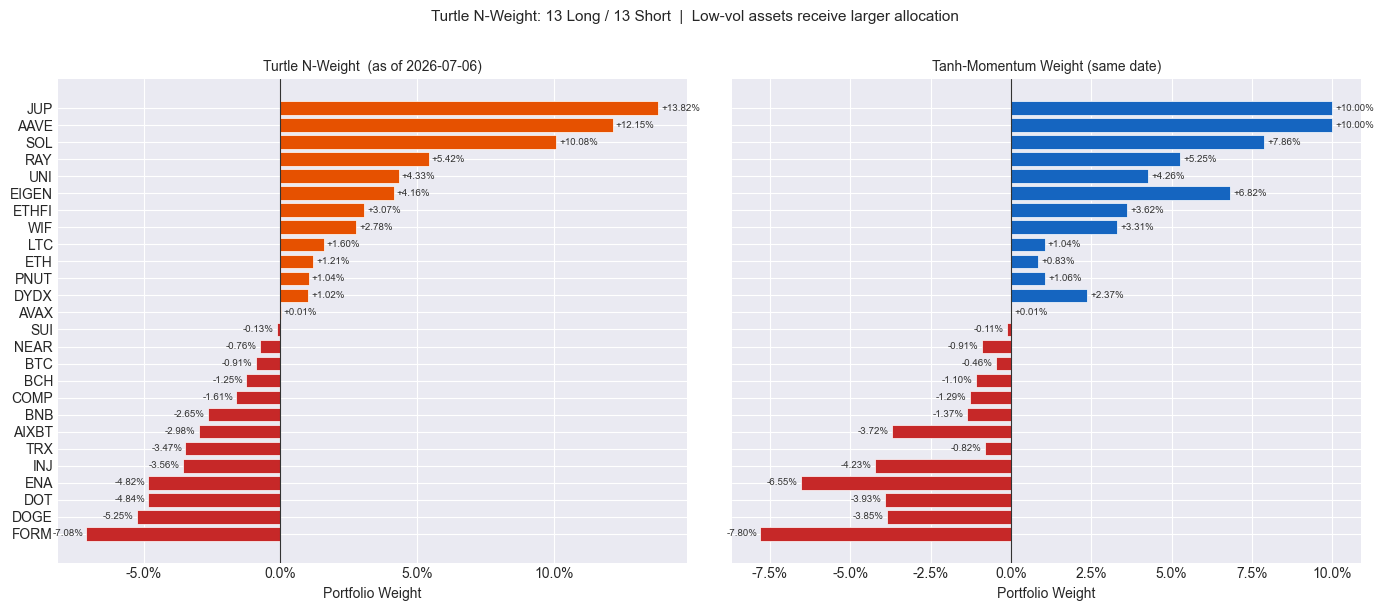


Top 3 LONG  (turtle): JUP, AAVE, SOL
Top 3 SHORT (turtle): DOT, DOGE, FORM

Highest N% (most volatile): DYDX  15.59%
Lowest  N% (least volatile): TRX  1.58%


In [22]:
last_date = results_turtle['df_weights'].index[-1]

w_turtle  = results_turtle['df_weights'].iloc[-1].sort_values(ascending=False)
w_momo    = results['df_weights'].reindex(columns=w_turtle.index).iloc[-1]

# Per-asset snapshot table
atr_snap  = results_turtle['df_atr'].iloc[-1]
npct_snap = results_turtle['df_n_pct'].iloc[-1]
price_snap= df_prices[w_turtle.index].iloc[-1]

snap_table = pd.DataFrame({
    'Turtle Weight (t)':  results_turtle['df_weights'].iloc[-1],
    'Tanh Weight (t)':    results['df_weights'].reindex(
                              columns=results_turtle['df_weights'].columns).iloc[-1],
    'ATR_20 (N)':         atr_snap,
    'N % of Price':       npct_snap * 100,
    'Price':              price_snap,
}).sort_values('Turtle Weight (t)', ascending=False)

snap_table['Direction'] = snap_table['Turtle Weight (t)'].apply(
    lambda x: 'LONG' if x > 0 else ('SHORT' if x < 0 else 'FLAT')
)

print(f'Turtle weights as of : {last_date.date()}')
print(f'Gross exposure check : {w_turtle.abs().sum():.6f}  (should be ≈ 1.0)')
print(f'Net exposure         : {w_turtle.sum()*100:+.2f}%')
print()

display(
    snap_table.style
    .format({
        'Turtle Weight (t)': '{:+.4f}',
        'Tanh Weight (t)':   '{:+.4f}',
        'ATR_20 (N)':        '{:,.4f}',
        'N % of Price':      '{:.3f}%',
        'Price':             '{:,.4f}',
    })
    .background_gradient(subset=['Turtle Weight (t)'], cmap='RdYlGn', vmin=-0.15, vmax=0.15)
    .background_gradient(subset=['Tanh Weight (t)'],   cmap='RdYlGn', vmin=-0.15, vmax=0.15)
    .background_gradient(subset=['N % of Price'],      cmap='RdYlGn_r', vmin=1, vmax=10)
    .set_caption(f'Turtle N-Weight Snapshot — {last_date.date()}  |  ATR_PERIOD={ATR_PERIOD}d')
)

# ── Side-by-side weight bar chart ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for ax, (w, color, title) in zip(axes, [
    (w_turtle, '#E65100', f'Turtle N-Weight  (as of {last_date.date()})'),
    (w_momo,   '#1565C0', f'Tanh-Momentum Weight (same date)'),
]):
    colors = [color if v > 0 else '#C62828' for v in w.values]
    bars   = ax.barh(w.index[::-1], w.values[::-1], color=colors[::-1],
                     edgecolor='white', linewidth=0.5)
    ax.axvline(0, color='#333', linewidth=0.8)
    ax.set_xlabel('Portfolio Weight', fontsize=10)
    ax.set_title(title, fontsize=10)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x*100:.1f}%'))
    for bar, val in zip(bars, w.values[::-1]):
        ax.text(
            val + (0.001 if val >= 0 else -0.001),
            bar.get_y() + bar.get_height() / 2,
            f'{val*100:+.2f}%',
            va='center', ha='left' if val >= 0 else 'right',
            fontsize=7, color='#333',
        )

n_long  = (w_turtle > 0).sum()
n_short = (w_turtle < 0).sum()
fig.suptitle(
    f'Turtle N-Weight: {n_long} Long / {n_short} Short  |  '
    f'Low-vol assets receive larger allocation',
    fontsize=11, y=1.01,
)
plt.tight_layout()
plt.show()

print(f'\nTop 3 LONG  (turtle): {", ".join(w_turtle[w_turtle > 0].head(3).index.tolist())}')
print(f'Top 3 SHORT (turtle): {", ".join(w_turtle[w_turtle < 0].tail(3).index.tolist())}')
print(f'\nHighest N% (most volatile): {npct_snap.idxmax()}  {npct_snap.max()*100:.2f}%')
print(f'Lowest  N% (least volatile): {npct_snap.idxmin()}  {npct_snap.min()*100:.2f}%')

In [23]:
results_turtle

{'eval_returns': date
 2021-07-06   -0.045502
 2021-07-07    0.001054
 2021-07-08    0.069924
 2021-07-09   -0.020778
 2021-07-10    0.016457
                 ...   
 2026-07-02   -0.028324
 2026-07-03   -0.030105
 2026-07-04    0.000235
 2026-07-05   -0.003605
 2026-07-06    0.011815
 Freq: D, Length: 1827, dtype: float64,
 'cum_returns': date
 2021-07-06    0.954498
 2021-07-07    0.955504
 2021-07-08    1.022317
 2021-07-09    1.001076
 2021-07-10    1.017551
                 ...   
 2026-07-02    3.641210
 2026-07-03    3.531590
 2026-07-04    3.532419
 2026-07-05    3.519684
 2026-07-06    3.561268
 Freq: D, Length: 1827, dtype: float64,
 'drawdowns': date
 2021-07-06    0.000000
 2021-07-07    0.000000
 2021-07-08    0.000000
 2021-07-09   -0.020778
 2021-07-10   -0.004662
                 ...   
 2026-07-02   -0.338971
 2026-07-03   -0.358871
 2026-07-04   -0.358721
 2026-07-05   -0.361033
 2026-07-06   -0.353483
 Freq: D, Length: 1827, dtype: float64,
 'weights_shifted':       